In [530]:
"""
What is RFM analysis?
RFM stands for recency, frequency, monetary value. In business analytics, 
we often use this concept to divide customers into different segments, 
like high-value customers, medium value customers or low-value customers, and similarly many others.

Let’s assume we are a company, our company name is geek, 
let’s perform the RFM analysis on our customers

Recency: How recently has the customer made a transaction with us
Frequency: How frequent is the customer in ordering/buying some product from us
Monetary: How much does the customer spend on purchasing products from us.
Getting Started
"""

'\nWhat is RFM analysis?\nRFM stands for recency, frequency, monetary value. In business analytics, \nwe often use this concept to divide customers into different segments, \nlike high-value customers, medium value customers or low-value customers, and similarly many others.\n\nLet’s assume we are a company, our company name is geek, \nlet’s perform the RFM analysis on our customers\n\nRecency: How recently has the customer made a transaction with us\nFrequency: How frequent is the customer in ordering/buying some product from us\nMonetary: How much does the customer spend on purchasing products from us.\nGetting Started\n'

In [531]:
import pandas as pd
import datetime as dt
import numpy as np

In [532]:
# importing the data
df = pd.read_csv("C:\\Users\\franc\\Datascience_python\\dataset\\rfm.csv")
df.head()

,Unnamed: 0,CustomerName,Recency,Frequency,Monetary,R_rank,F_rank,M_rank,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Customer_segment
0,0,Aaron Bergman,16,89,120359.56970,397.5,770.5,713,50.994227,96.796482,96.796482,89.926144,High Value Customer
1,1,Aaron Hawkins,12,56,102027.89570,486.5,221.5,637,62.411802,27.826633,27.826633,33.014409,Low value Customer
2,2,Aaron Smayling,23,60,64406.23580,298.0,308.0,309,38.229634,38.693467,38.693467,38.623892,Low value Customer
3,3,Adam Bellavance,35,68,109573.00940,173.0,495.0,679,22.193714,62.185930,62.185930,56.187097,Medium Value Customer
4,4,Adam Hart,2,84,91431.54582,699.0,734.5,569,89.672867,92.273869,92.273869,91.883719,High Value Customer


## method 1

In [533]:
rfm1_df = df[['CustomerName','Recency','Frequency','Monetary']]
rfm1_df.head()

,CustomerName,Recency,Frequency,Monetary
0,Aaron Bergman,16,89,120359.56970
1,Aaron Hawkins,12,56,102027.89570
2,Aaron Smayling,23,60,64406.23580
3,Adam Bellavance,35,68,109573.00940
4,Adam Hart,2,84,91431.54582


## method 2

In [534]:
frequency_df = df[['CustomerName', 'Frequency']]
frequency_df.head().sort_values(by='Frequency', ascending=False)

,CustomerName,Frequency
0,Aaron Bergman,89
4,Adam Hart,84
3,Adam Bellavance,68
2,Aaron Smayling,60
1,Aaron Hawkins,56


In [535]:
monetary_df = df[['CustomerName', 'Monetary']]
monetary_df.head().sort_values(by='Monetary', ascending=False)

,CustomerName,Monetary
0,Aaron Bergman,120359.56970
3,Adam Bellavance,109573.00940
1,Aaron Hawkins,102027.89570
4,Adam Hart,91431.54582
2,Aaron Smayling,64406.23580


In [536]:
df_recency = df[['CustomerName','Recency']]
df_recency.head(5).sort_values(by='Recency',ascending=False)

,CustomerName,Recency
3,Adam Bellavance,35
2,Aaron Smayling,23
0,Aaron Bergman,16
1,Aaron Hawkins,12
4,Adam Hart,2


# Create Recency, Frequency and Monetary Data dataframe

In [537]:
# Merge Recency, Frequency and Monetary Data
rf_df = df_recency.merge(frequency_df, on='CustomerName')
rfm_df = rf_df.merge(monetary_df, on='CustomerName')
rfm_df.head()

,CustomerName,Recency,Frequency,Monetary
0,Aaron Bergman,16,89,120359.56970
1,Aaron Hawkins,12,56,102027.89570
2,Aaron Smayling,23,60,64406.23580
3,Adam Bellavance,35,68,109573.00940
4,Adam Hart,2,84,91431.54582


# Rank Customers Based on Recency, Frequency and Monetary
Lower recency is better while higher frequency and monetary values are better.

The rank() function assigns a rank to each customer.


In [538]:
rfm_df['R_rank'] = rfm_df['Recency'].rank(ascending=False)
rfm_df['F_rank'] = rfm_df['Frequency'].rank(ascending=True)
rfm_df['M_rank'] = rfm_df['Monetary'].rank(ascending=True)

## Normalize the Ranks
normalize the ranks to a scale of 0-100 to make them easier to compare.

makes the ranks more consistent across different customers and helps in calculating the final RFM score.

In [539]:
rfm_df['R_rank_norm'] = (rfm_df['R_rank'] / rfm_df['R_rank'].max()) * 100
rfm_df['F_rank_norm'] = (rfm_df['F_rank'] / rfm_df['F_rank'].max()) * 100
rfm_df['M_rank_norm'] = (rfm_df['M_rank'] / rfm_df['M_rank'].max()) * 100

## Drop Individual Ranks

In [540]:
rfm_df.drop(columns=['R_rank','F_rank','M_rank'],inplace=True)
rfm_df.head()

,CustomerName,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm
0,Aaron Bergman,16,89,120359.56970,50.994227,96.796482,89.572864
1,Aaron Hawkins,12,56,102027.89570,62.411802,27.826633,80.025126
2,Aaron Smayling,23,60,64406.23580,38.229634,38.693467,38.819095
3,Adam Bellavance,35,68,109573.00940,22.193714,62.185930,85.301508
4,Adam Hart,2,84,91431.54582,89.672867,92.273869,71.482412


## Calculate RFM Score
calculate the RFM score by assigning different weights to Recency, Frequency and Monetary values. 

The weights are based on the business goals, with Monetary given the highest weight.

In [541]:

rfm_df['RFM_Score'] = 0.15 * rfm_df['R_rank_norm'] 
+ 0.28 * rfm_df['F_rank_norm']
+ 0.57 * rfm_df['M_rank_norm']

#  scale the RFM_Score down by multiplying it by 0.05.
rfm_df['RFM_Score'] *= 0.45
rfm_df = rfm_df.round(2)
rfm_df.head()


,CustomerName,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score
0,Aaron Bergman,16,89,120359.57,50.99,96.80,89.57,3.44
1,Aaron Hawkins,12,56,102027.90,62.41,27.83,80.03,4.21
2,Aaron Smayling,23,60,64406.24,38.23,38.69,38.82,2.58
3,Adam Bellavance,35,68,109573.01,22.19,62.19,85.30,1.50
4,Adam Hart,2,84,91431.55,89.67,92.27,71.48,6.05


In [542]:
'''
rfm_df['RFM_Score'] = 0.15 * rfm_df['R_rank_norm'] 
+ 0.28 * rfm_df['F_rank_norm']
+ 0.57 * rfm_df['M_rank_norm']

#  scale the RFM_Score down by multiplying it by 0.05.
rfm_df['RFM_Score'] *= 0.35
rfm_df = rfm_df.round(2)
rfm_df.head()
'''

"\nrfm_df['RFM_Score'] = 0.15 * rfm_df['R_rank_norm'] \n+ 0.28 * rfm_df['F_rank_norm']\n+ 0.57 * rfm_df['M_rank_norm']\n\n#  scale the RFM_Score down by multiplying it by 0.05.\nrfm_df['RFM_Score'] *= 0.35\nrfm_df = rfm_df.round(2)\nrfm_df.head()\n"

In [543]:
rfm_df[['CustomerName', 'RFM_Score']].head(7).sort_values(by='RFM_Score',ascending=False)

,CustomerName,RFM_Score
4,Adam Hart,6.05
1,Aaron Hawkins,4.21
5,Adam Shillingsburg,3.63
0,Aaron Bergman,3.44
2,Aaron Smayling,2.58
6,Adrian Barton,2.21
3,Adam Bellavance,1.50


## Segment Customers Based on RFM Score
We classify customers into different segments based on their RFM scores. 

This helps to categorize them into groups like Top Customers, High Value Customers, etc.

In [544]:

conditions = [
    rfm_df['RFM_Score'] >= 5.5,
    rfm_df['RFM_Score'] >= 4.5,
    rfm_df['RFM_Score'] >= 2.5,
    rfm_df['RFM_Score'] >= 1.6
]

choices = [
    'Top Customer',
    'High value Customer',
    'Medium value Customer',
    'Low value Customer'
]

rfm_df['Customer_segment'] = np.select(conditions, choices, default = 'Very low value Customer')


In [545]:
'''
conditions = [
    rfm_df['RFM_Score'] > 5.2,
    rfm_df['RFM_Score'] > 4.9,
    rfm_df['RFM_Score'] > 3.3,
    rfm_df['RFM_Score'] > 1
]

choices = [
    'Top Customer',
    'High value Customer',
    'Medium value Customer',
    'Low value Customer'
]

rfm_df['Customer_segment'] = np.select(conditions, choices, default='Very low value Customer')
'''

"\nconditions = [\n    rfm_df['RFM_Score'] > 5.2,\n    rfm_df['RFM_Score'] > 4.9,\n    rfm_df['RFM_Score'] > 3.3,\n    rfm_df['RFM_Score'] > 1\n]\n\nchoices = [\n    'Top Customer',\n    'High value Customer',\n    'Medium value Customer',\n    'Low value Customer'\n]\n\nrfm_df['Customer_segment'] = np.select(conditions, choices, default='Very low value Customer')\n"

## Display Customer Segments


In [546]:
rfm_df[['CustomerName', 'RFM_Score', 'Customer_segment']].head(20)

,CustomerName,RFM_Score,Customer_segment
0,Aaron Bergman,3.44,Medium value Customer
1,Aaron Hawkins,4.21,Medium value Customer
2,Aaron Smayling,2.58,Medium value Customer
3,Adam Bellavance,1.50,Very low value Customer
4,Adam Hart,6.05,Top Customer
5,Adam Shillingsburg,3.63,Medium value Customer
6,Adrian Barton,2.21,Low value Customer
7,Adrian Hane,2.88,Medium value Customer
8,Adrian Shami,1.12,Very low value Customer
9,Aimee Bixby,1.50,Very low value Customer


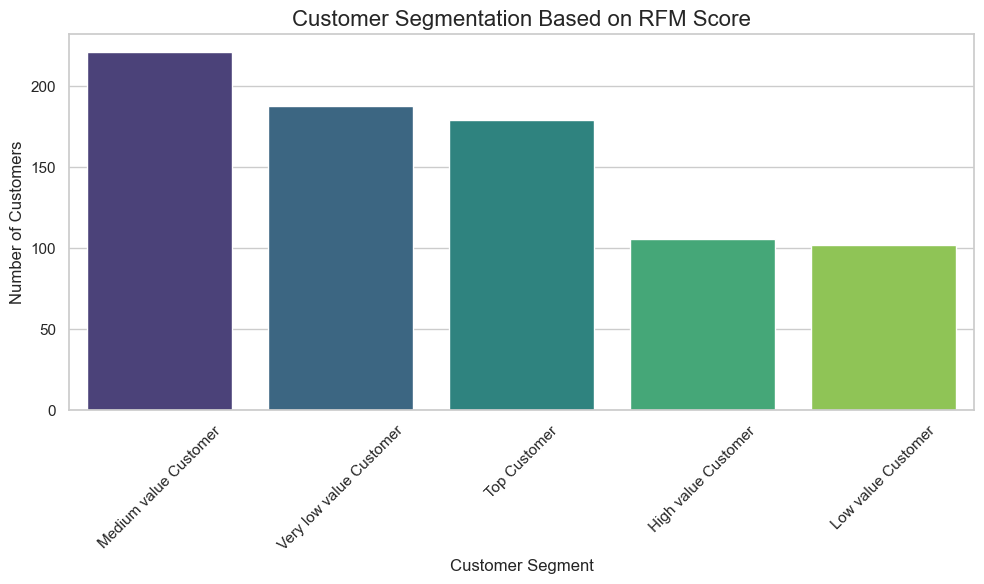

In [547]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count customer segments
segment_counts = rfm_df['Customer_segment'].value_counts().sort_values(ascending=False).reset_index()
segment_counts.columns = ['Customer_segment', 'Count']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=segment_counts,
    x='Customer_segment',
    y='Count',
    hue='Customer_segment',
    palette='viridis',
    legend=False  # Suppress legend since it's redundant
)

# Labels and title
plt.title('Customer Segmentation Based on RFM Score', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Visualize Customer Segments with a Pie Chart

we create a pie chart to visualize the distribution of customers across different segments. This helps in understanding how many customers belong to each segment.


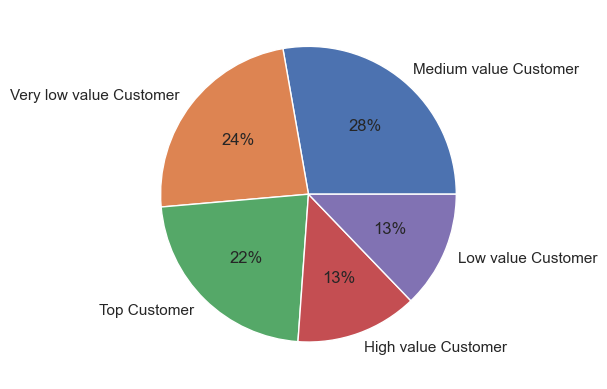

In [548]:
plt.pie(rfm_df['Customer_segment'].value_counts(), labels= rfm_df['Customer_segment'].value_counts().index,
        autopct='%.0f%%')
plt.show()

In [549]:
rfm_df.to_csv('C:\\Users\\franc\\Datascience_python\\dataset\\my_rfm.csv')